<a href="https://colab.research.google.com/github/yakdudi12/IID/blob/main/PrimeraClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Mount Google Drive

To access files stored in Google Drive from Colab, you need to mount your Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive
!rm -rf .git

/content/drive/MyDrive


In [6]:
# 1. Crear una carpeta dedicada para la materia (si no existe ya)
!mkdir -p /content/drive/MyDrive/ITBA_IID

# 2. Entrar a esa carpeta específica
%cd /content/drive/MyDrive/ITBA_IID

# 3. Inicializar Git SOLO acá adentro
!git init
!git status

/content/drive/MyDrive/ITBA_IID
Reinitialized existing Git repository in /content/drive/MyDrive/ITBA_IID/.git/
On branch master

No commits yet

nothing to commit (create/copy files and use "git add" to track)


In [8]:
!git config --global user.name "S4nty"
!git config --global user.email "santiagoluisbritez@gmail.com"

In [11]:
# 1. Agregar el remoto origin
!git remote add origin https://github.com/yakdudi12/IID.git

# 2. Verificar que se haya guardado bien
!git remote -v

origin	https://github.com/yakdudi12/IID.git (fetch)
origin	https://github.com/yakdudi12/IID.git (push)


In [12]:
# 3. Establecer rama main y bajar cambios iniciales
!git branch -M main
!git pull origin main --allow-unrelated-histories

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 9 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (9/9), 4.54 KiB | 51.00 KiB/s, done.
From https://github.com/yakdudi12/IID
 * branch            main       -> FETCH_HEAD
 * [new branch]      main       -> origin/main


### Download a dataset from Kaggle

To download datasets from Kaggle, you first need to install the Kaggle API client and set up your credentials.

1.  **Get your Kaggle API key**: Go to your Kaggle account settings (kaggle.com/your-username/account) and click 'Create New API Token'. This will download a `kaggle.json` file.
2.  **Upload `kaggle.json`**: In the Colab file browser (left sidebar), navigate to 'Files' (the folder icon), and upload your `kaggle.json` file to the root directory (or `~/.kaggle/`). If you upload it to the root, the following code will move it to the correct location.
3.  **Set permissions**: Ensure the `kaggle.json` file has the correct permissions (read-only for your user) to prevent warnings.

In [ ]:
# Install the Kaggle API client
!pip install kaggle

# Create a .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Move the kaggle.json file to the .kaggle directory (assuming you uploaded it to the root)
# If you manually uploaded it to ~/.kaggle/, you can skip this step.
!mv kaggle.json ~/.kaggle/

# Set permissions for the kaggle.json file
!chmod 600 ~/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Now that the Kaggle API is set up, you can download a dataset. I'll use the 'Iris Species' dataset as an example. You can replace `'uciml/iris'` with the dataset identifier of your choice (found on the Kaggle dataset page, e.g., `username/dataset-name`).

In [ ]:
# Download the dataset (e.g., Stroke Prediction Dataset)
# Replace 'fedesoriano/stroke-prediction-dataset' with your desired dataset identifier.
!kaggle datasets download -d fedesoriano/stroke-prediction-dataset

# Unzip the downloaded file (Kaggle datasets are often zipped)
# The default download location is usually the content root '/content/'
!unzip -o stroke-prediction-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset
License(s): copyright-authors
100% 67.4k/67.4k [00:00<00:00, 57.8MB/s]

Archive:  stroke-prediction-dataset.zip
  inflating: healthcare-dataset-stroke-data.csv  


Finally, we can load the downloaded CSV file into a pandas DataFrame and display its head.

In [ ]:
import pandas as pd

# Load the dataset (assuming the unzipped CSV file is named 'healthcare-dataset-stroke-data.csv')
# You might need to adjust the filename based on the actual CSV name inside the zip.
df_kaggle = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Display the first 5 rows of the DataFrame
display(df_kaggle.head())

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Statistical Summary of the Dataset

Let's get a quick statistical overview of the numerical columns in the `df_kaggle` DataFrame using the `.describe()` method.

In [ ]:
display(df_kaggle.describe())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [ ]:
display(df_kaggle.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


None

### Boxplots of Numerical Variables

Now, let's visualize the distribution of numerical variables using boxplots to identify potential outliers and understand their spread.

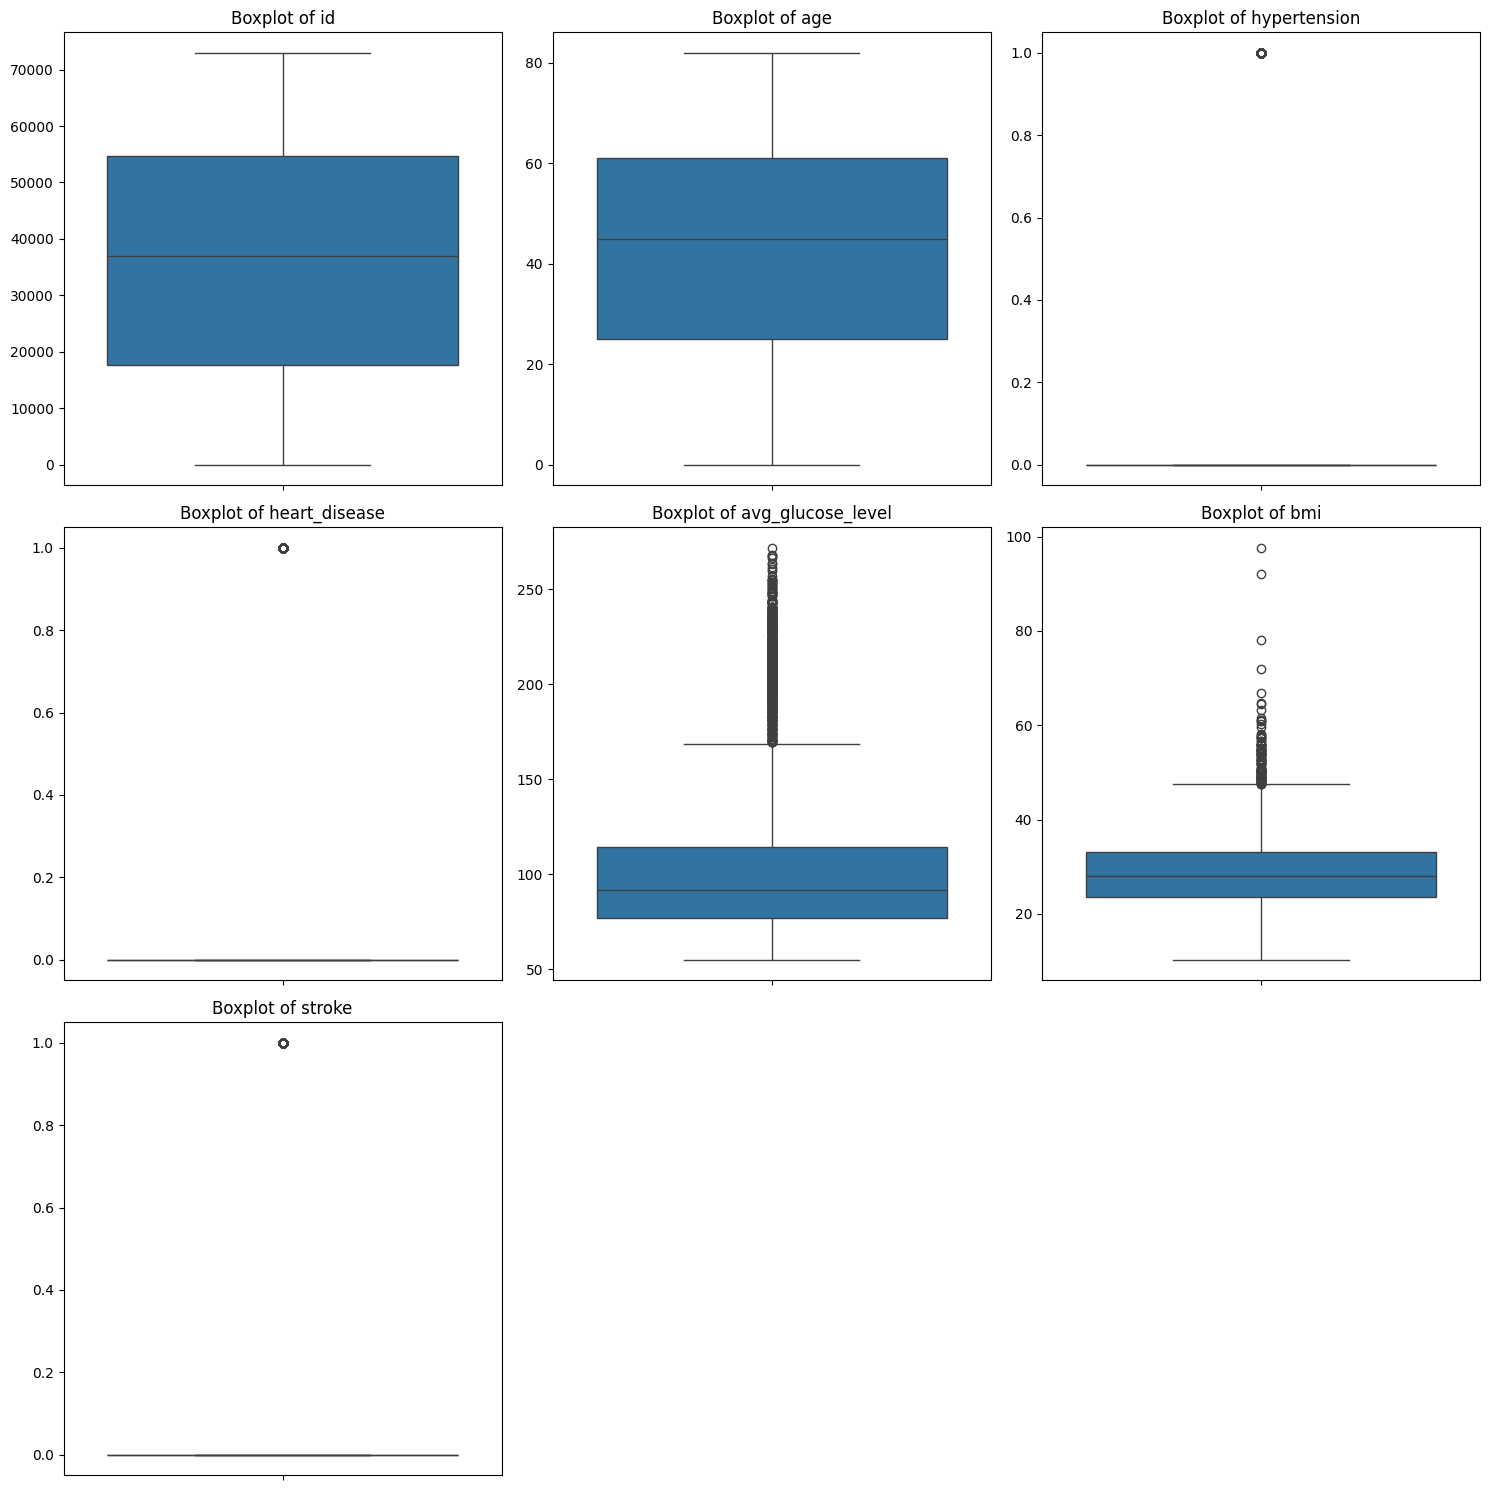

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for boxplots
numerical_cols = df_kaggle.select_dtypes(include=['number']).columns

if len(numerical_cols) == 0:
    print("No numerical columns found to plot boxplots.")
else:
    plt.figure(figsize=(15, 5 * ((len(numerical_cols) + 2) // 3))) # Adjust figure size dynamically
    for i, col in enumerate(numerical_cols):
        plt.subplot((len(numerical_cols) + 2) // 3, 3, i + 1)
        sns.boxplot(y=df_kaggle[col])
        plt.title(f'Boxplot of {col}')
        plt.ylabel('') # Remove y-label to avoid clutter
    plt.tight_layout()
    plt.show()

### Detailed Data Analysis: Going Beyond the Surface

Now, let's perform a more in-depth analysis of the `df_kaggle` dataset to uncover hidden patterns and characteristics that might not be evident from simple `.describe()` or boxplots.

#### 1. Missing Value Analysis

It's crucial to understand where and how much data is missing. This can influence data imputation strategies or decisions to drop columns/rows.

In [ ]:
print('Missing values in each column:')
display(df_kaggle.isnull().sum())

Missing values in each column:


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


#### 2. Distribution of the Target Variable: 'stroke'

Understanding the balance of the target variable is vital, especially in classification problems like stroke prediction.

/tmp/ipykernel_2249/3041100282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df_kaggle, palette='viridis')


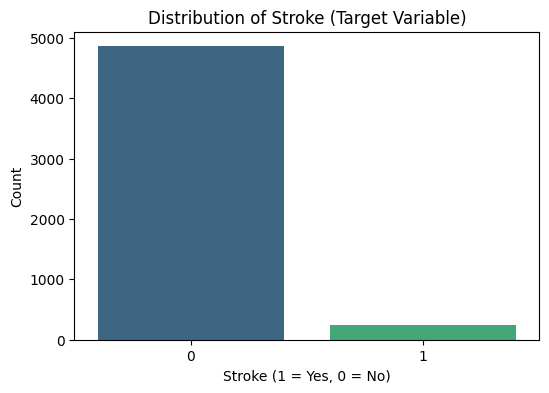


Percentage of Stroke cases:
stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df_kaggle, palette='viridis')
plt.title('Distribution of Stroke (Target Variable)')
plt.xlabel('Stroke (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

stroke_percentage = df_kaggle['stroke'].value_counts(normalize=True) * 100
print(f"\nPercentage of Stroke cases:\n{stroke_percentage}")

#### 3. Analysis of Categorical Variables

Let's look at the unique values and their counts for key categorical features to identify potential issues or insights.


Unique values and their counts for 'gender':


,count
gender,
Female,2994
Male,2115
Other,1


/tmp/ipykernel_2249/1383513247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_kaggle, palette='pastel', order = df_kaggle[col].value_counts().index)


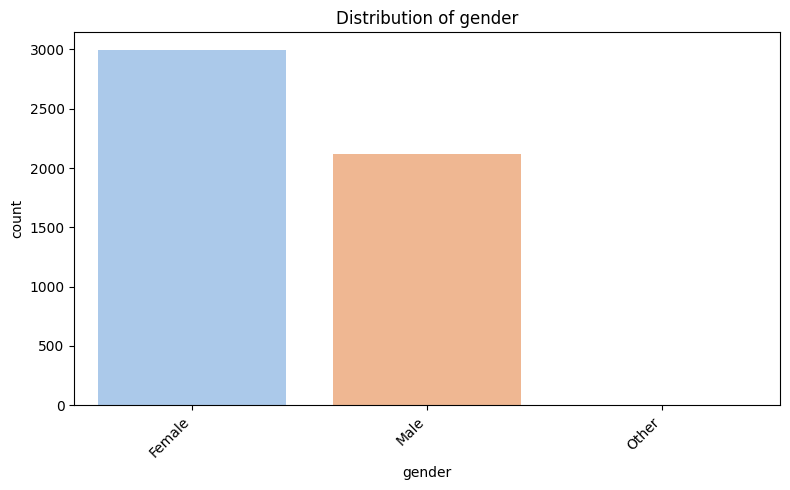


Unique values and their counts for 'ever_married':


,count
ever_married,
Yes,3353
No,1757


/tmp/ipykernel_2249/1383513247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_kaggle, palette='pastel', order = df_kaggle[col].value_counts().index)


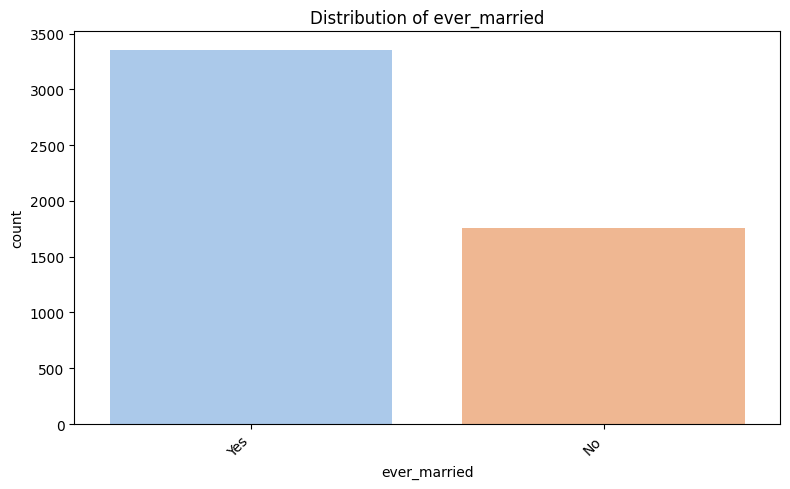


Unique values and their counts for 'work_type':


,count
work_type,
Private,2925
Self-employed,819
children,687
Govt_job,657
Never_worked,22


/tmp/ipykernel_2249/1383513247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_kaggle, palette='pastel', order = df_kaggle[col].value_counts().index)


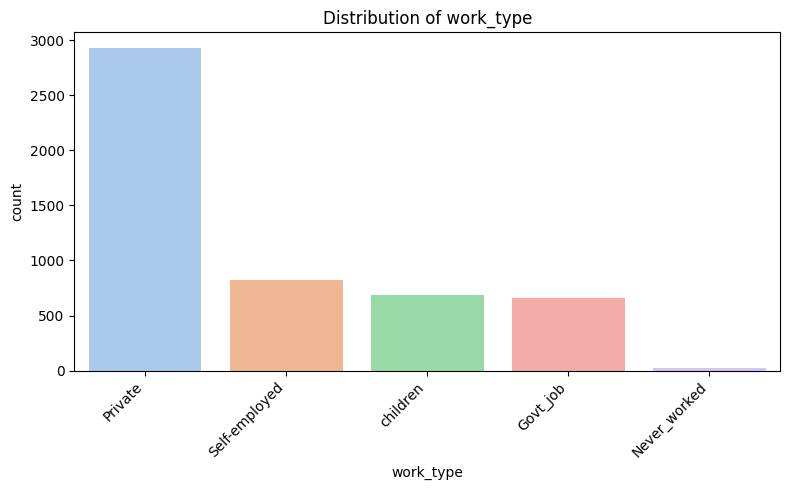


Unique values and their counts for 'Residence_type':


,count
Residence_type,
Urban,2596
Rural,2514


/tmp/ipykernel_2249/1383513247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_kaggle, palette='pastel', order = df_kaggle[col].value_counts().index)


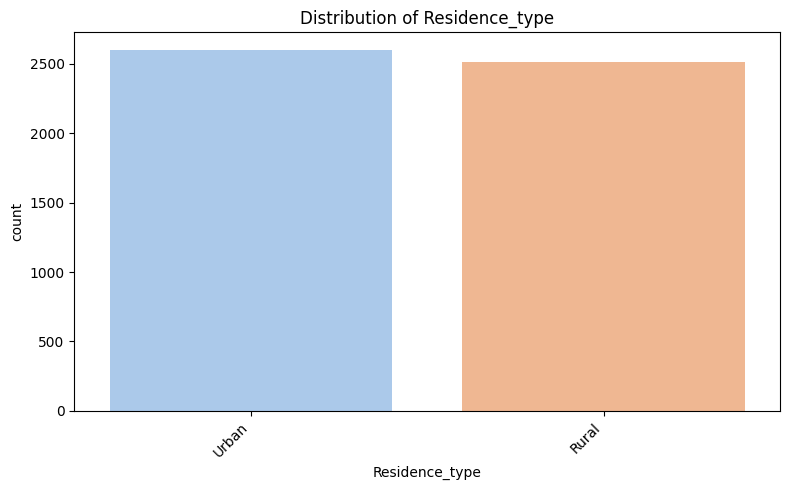


Unique values and their counts for 'smoking_status':


,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


/tmp/ipykernel_2249/1383513247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df_kaggle, palette='pastel', order = df_kaggle[col].value_counts().index)


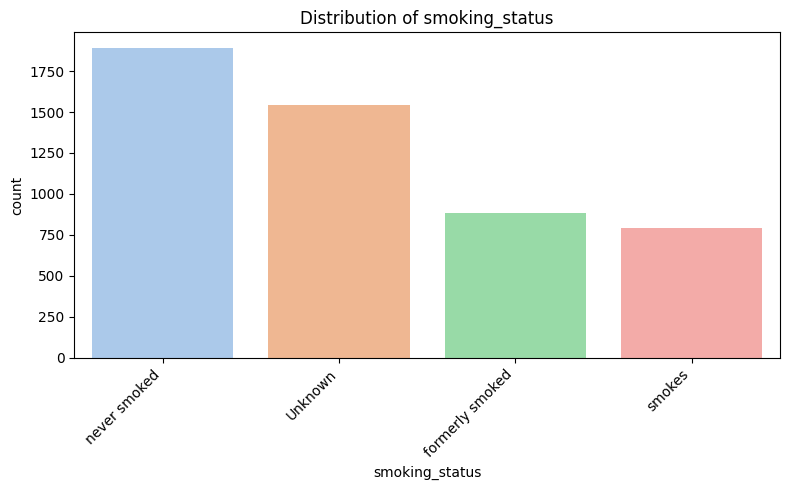

In [ ]:
categorical_cols = df_kaggle.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\nUnique values and their counts for '{col}':")
    display(df_kaggle[col].value_counts())
    plt.figure(figsize=(8, 5))
    sns.countplot(x=col, data=df_kaggle, palette='pastel', order = df_kaggle[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

#### 4. Correlation Matrix of Numerical Features

Understanding the linear relationships between numerical features can help in feature selection and model interpretation. A heatmap provides a clear visual representation.

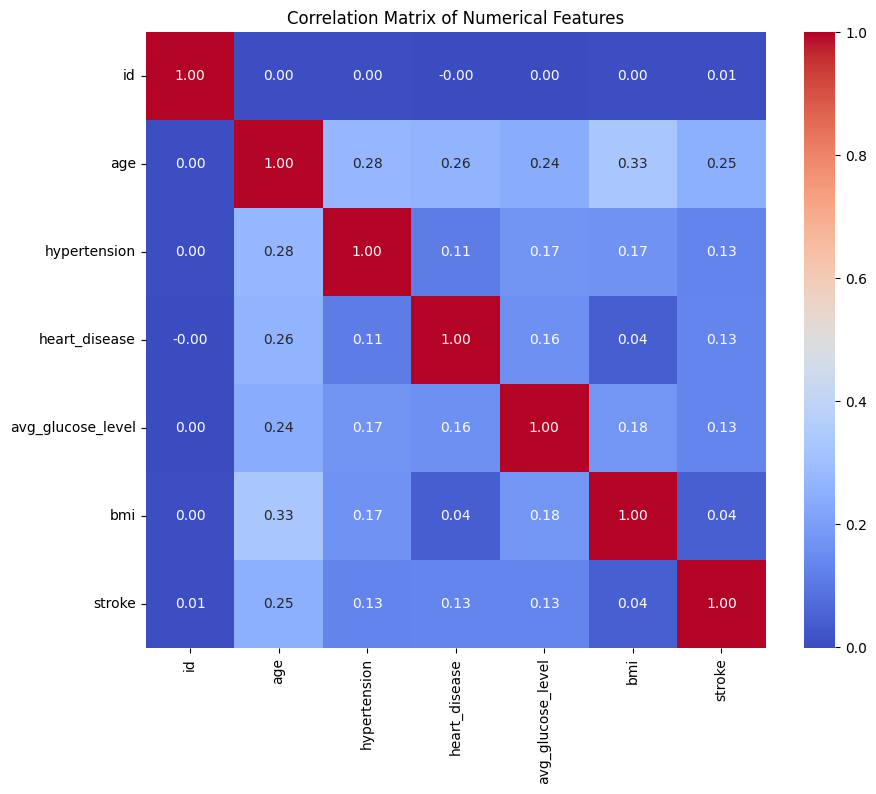

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_kaggle[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()